# **Situação Problema**

**Demanda**  
Na reunião entre nosso time e o time de marketing, surgiu a ideia de criarmos um modelo de Machine Learning capaz de classificar nossos clientes entre possíveis cancelamentos ou não.

Basearemos esse modelo nos dados históricos da empresa, relacionando as características dos clientes em relação ao contrato estabelecido e as ocorrências de cancelamento.

Nossa liderança técnica estabelece que o recomendado para esse problema é a utilização do PySpark, uma vez que o time de marketing conta com um grande volume de dados acerca de clientes. O PySpark é a única ferramenta capaz de processar todos esses dados e tornar a nossa pesquisa possível.

**A ferramenta**  
Vamos utilizar o ambiente do Google Colab nesse projeto, muito bem configurado, preparado, e conta com diversas bibliotecas pré-instaladas - exceto o PySpark.

# **Base de Dados**

In [2]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [4]:
spark = (
    SparkSession.builder\
        .master("local[*]")\
        .appName("Classificacao Churn")\
        .config("spark.some.config.option", "some-value")\
        .getOrCreate()
)

In [5]:
df = spark.read.csv('/content/dados_clientes.csv', header=True, inferSchema=True, sep=',')

In [6]:
df.show(10)

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|
+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+
|  0|  Nao|         0|    Sim|        Nao|              1|         Nao|    SemServicoTelefonico|        DSL|            Nao|         Sim|              Nao|           Nao|    Nao|            Nao| Mensalmente|         Sim|BoletoEletronico|       

In [7]:
df.toPandas().head()

,id,Churn,Mais65anos,Conjuge,Dependentes,MesesDeContrato,TelefoneFixo,MaisDeUmaLinhaTelefonica,Internet,SegurancaOnline,BackupOnline,SeguroDispositivo,SuporteTecnico,TVaCabo,StreamingFilmes,TipoContrato,ContaCorreio,MetodoPagamento,MesesCobrados
0,0,Nao,0,Sim,Nao,1,Nao,SemServicoTelefonico,DSL,Nao,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,BoletoEletronico,29.85
1,1,Nao,0,Nao,Nao,34,Sim,Nao,DSL,Sim,Nao,Sim,Nao,Nao,Nao,UmAno,Nao,Boleto,56.95
2,2,Sim,0,Nao,Nao,2,Sim,Nao,DSL,Sim,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,Boleto,53.85
3,3,Nao,0,Nao,Nao,45,Nao,SemServicoTelefonico,DSL,Sim,Nao,Sim,Sim,Nao,Nao,UmAno,Nao,DebitoEmConta,42.30
4,4,Sim,0,Nao,Nao,2,Sim,Nao,FibraOptica,Nao,Nao,Nao,Nao,Nao,Nao,Mensalmente,Sim,BoletoEletronico,70.70


In [8]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Churn: string (nullable = true)
 |-- Mais65anos: integer (nullable = true)
 |-- Conjuge: string (nullable = true)
 |-- Dependentes: string (nullable = true)
 |-- MesesDeContrato: integer (nullable = true)
 |-- TelefoneFixo: string (nullable = true)
 |-- MaisDeUmaLinhaTelefonica: string (nullable = true)
 |-- Internet: string (nullable = true)
 |-- SegurancaOnline: string (nullable = true)
 |-- BackupOnline: string (nullable = true)
 |-- SeguroDispositivo: string (nullable = true)
 |-- SuporteTecnico: string (nullable = true)
 |-- TVaCabo: string (nullable = true)
 |-- StreamingFilmes: string (nullable = true)
 |-- TipoContrato: string (nullable = true)
 |-- ContaCorreio: string (nullable = true)
 |-- MetodoPagamento: string (nullable = true)
 |-- MesesCobrados: double (nullable = true)



In [9]:
df.count()

10348

In [10]:
df.groupBy('Churn').count().toPandas()

,Churn,count
0,Sim,5174
1,Nao,5174


In [11]:
df.select('Internet').groupBy('Internet').count().show()

+-----------+-----+
|   Internet|count|
+-----------+-----+
|FibraOptica| 5401|
|        Nao| 1741|
|        DSL| 3206|
+-----------+-----+



In [12]:
df.groupBy('Internet').count().show()

+-----------+-----+
|   Internet|count|
+-----------+-----+
|FibraOptica| 5401|
|        Nao| 1741|
|        DSL| 3206|
+-----------+-----+



In [13]:
df.summary().show()

+-------+-----------------+-----+------------------+-------+-----------+------------------+------------+------------------------+--------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+------------------+
|summary|               id|Churn|        Mais65anos|Conjuge|Dependentes|   MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio|MetodoPagamento|     MesesCobrados|
+-------+-----------------+-----+------------------+-------+-----------+------------------+------------+------------------------+--------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+------------------+
|  count|            10348|10348|             10348|  10348|      10348|             10348|       10348|                   10348|   10348|    

In [14]:
from pyspark.sql import functions as F

In [15]:
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+---+-----+----------+-------+-----------+---------------+------------+------------------------+--------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+-------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio|MetodoPagamento|MesesCobrados|
+---+-----+----------+-------+-----------+---------------+------------+------------------------+--------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+-------------+
|  0|    0|         0|      0|          0|              0|           0|                       0|       0|              0|           0|                0|             0|      0|              0|           0|           0|              0|            0|
+---+---

# **Transformando os Dados**

In [16]:
colunas_categoricas = [
    nome_coluna for nome_coluna, tipo_coluna in df.dtypes
    if tipo_coluna in ('string')
]

# Seleciona apenas as colunas filtradas
colunas_categoricas = df.select(*colunas_categoricas)
colunas_categoricas.show()

+-----+-------+-----------+------------+------------------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+------------+----------------+
|Churn|Conjuge|Dependentes|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|   SegurancaOnline|      BackupOnline| SeguroDispositivo|    SuporteTecnico|           TVaCabo|   StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|
+-----+-------+-----------+------------+------------------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+------------+----------------+
|  Nao|    Sim|        Nao|         Nao|    SemServicoTelefonico|        DSL|               Nao|               Sim|               Nao|               Nao|               Nao|               Nao| Mensalmente|         Sim|BoletoEletronico|
|  Nao|    Nao|        Nao|         Sim|                    

In [17]:
colunas_binarias = ['Churn','Conjuge', 'Dependentes','TelefoneFixo','MaisDeUmaLinhaTelefonica',
                    'SegurancaOnline','BackupOnline','SeguroDispositivo','SuporteTecnico',
                    'TVaCabo','StreamingFilmes','ContaCorreio'
                    ]

In [18]:
# Initialize df_alterado with the original DataFrame to start transformations
df_alterado = df

for c in colunas_binarias:
    # Apply the transformation: if the column value is 'SemServicoInternet' OR 'SemServicoTelefonico', replace with 'Nao', otherwise keep the original value
    df_alterado = df_alterado.withColumn(c, F.when((F.col(c) == 'SemServicoInternet') | (F.col(c) == 'SemServicoTelefonico'), 'Nao').otherwise(F.col(c))
    )

In [19]:
from pyspark.ml.feature import StringIndexer

# O indexador vai mapear a categoria mais frequente para 0.0 e a outra para 1.0
indexer = StringIndexer(
    inputCols=colunas_binarias,
    outputCols= [col + '_bin' for col in colunas_binarias]
)

# Aplica a transformação
df_transformado = indexer.fit(df_alterado).transform(df_alterado)
df_transformado = df_transformado.drop(*colunas_binarias)

In [20]:
df_transformado.show()

+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+
| id|Mais65anos|MesesDeContrato|   Internet|TipoContrato| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTecnico_bin|TVaCabo_bin|StreamingFilmes_bin|ContaCorreio_bin|
+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+
|  0|         0|              1|        DSL| Mensalmente|BoletoEletronico|        29.85|      0.0|  

In [21]:
df_transformado.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Mais65anos: integer (nullable = true)
 |-- MesesDeContrato: integer (nullable = true)
 |-- Internet: string (nullable = true)
 |-- TipoContrato: string (nullable = true)
 |-- MetodoPagamento: string (nullable = true)
 |-- MesesCobrados: double (nullable = true)
 |-- Churn_bin: double (nullable = false)
 |-- Conjuge_bin: double (nullable = false)
 |-- Dependentes_bin: double (nullable = false)
 |-- TelefoneFixo_bin: double (nullable = false)
 |-- MaisDeUmaLinhaTelefonica_bin: double (nullable = false)
 |-- SegurancaOnline_bin: double (nullable = false)
 |-- BackupOnline_bin: double (nullable = false)
 |-- SeguroDispositivo_bin: double (nullable = false)
 |-- SuporteTecnico_bin: double (nullable = false)
 |-- TVaCabo_bin: double (nullable = false)
 |-- StreamingFilmes_bin: double (nullable = false)
 |-- ContaCorreio_bin: double (nullable = false)



In [22]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer

colunas_categoricas = [nome_coluna for nome_coluna, tipo_coluna in df_transformado.dtypes if tipo_coluna in ('string')]

# First, index the string columns using StringIndexer
indexer_categoricas = StringIndexer(
    inputCols=colunas_categoricas,
    outputCols=[c + '_indexed' for c in colunas_categoricas]
)

df_indexed = indexer_categoricas.fit(df_transformado).transform(df_transformado)

# Now, apply OneHotEncoder to the indexed columns
encoder = OneHotEncoder(
    inputCols=[c + '_indexed' for c in colunas_categoricas],
    outputCols=[c + '_vec' for c in colunas_categoricas]
)

df_transformado = encoder.fit(df_indexed).transform(df_indexed)
df_transformado.show()

+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+
| id|Mais65anos|MesesDeContrato|   Internet|TipoContrato| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTecnico_bin|TVaCabo_bin|StreamingFilmes_bin|ContaCorreio_bin|Internet_indexed|TipoContrato_indexed|MetodoPagamento_indexed| Internet_vec|TipoContrato_vec|MetodoPagamento_vec|
+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+--

In [23]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "Mais65anos",
        "MesesDeContrato",
        "MesesCobrados",

        "Conjuge_bin",
        "Dependentes_bin",
        "TelefoneFixo_bin",
        "MaisDeUmaLinhaTelefonica_bin",
        "SegurancaOnline_bin",
        "BackupOnline_bin",
        "SeguroDispositivo_bin",
        "SuporteTecnico_bin",
        "TVaCabo_bin",
        "StreamingFilmes_bin",
        "ContaCorreio_bin",

        "Internet_vec",
        "TipoContrato_vec",
        "MetodoPagamento_vec"
    ],
    outputCol="features"
)

df_transformado = assembler.transform(df_transformado)

In [24]:
df_transformado.show()

+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+--------------------+
| id|Mais65anos|MesesDeContrato|   Internet|TipoContrato| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTecnico_bin|TVaCabo_bin|StreamingFilmes_bin|ContaCorreio_bin|Internet_indexed|TipoContrato_indexed|MetodoPagamento_indexed| Internet_vec|TipoContrato_vec|MetodoPagamento_vec|            features|
+---+----------+---------------+-----------+------------+----------------+-------------+---------+-----------+---------------+------

In [25]:
df_transformado.select("features", "Churn_bin").show(truncate=False)

+-----------------------------------------------------------------------------------------+---------+
|features                                                                                 |Churn_bin|
+-----------------------------------------------------------------------------------------+---------+
|(21,[1,2,3,5,8,15,16,18],[1.0,29.85,1.0,1.0,1.0,1.0,1.0,1.0])                            |0.0      |
|(21,[1,2,7,9,13,15,19],[34.0,56.95,1.0,1.0,1.0,1.0,1.0])                                 |0.0      |
|(21,[1,2,7,8,15,16,19],[2.0,53.85,1.0,1.0,1.0,1.0,1.0])                                  |1.0      |
|(21,[1,2,5,7,9,10,13,15,20],[45.0,42.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                     |0.0      |
|(21,[1,2,14,16,18],[2.0,70.7,1.0,1.0,1.0])                                               |1.0      |
|(21,[1,2,6,9,11,12,14,16,18],[8.0,99.65,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                    |1.0      |
|(21,[1,2,4,6,8,11,14,16],[22.0,89.1,1.0,1.0,1.0,1.0,1.0,1.0])                    

In [26]:
df_transformado.groupBy("Churn_bin").count().show()

+---------+-----+
|Churn_bin|count|
+---------+-----+
|      0.0| 5174|
|      1.0| 5174|
+---------+-----+



## **Pipeline**

In [27]:
# Agora vamos utilizar os dados brutos e aplicar o pipeline
# Mas vamos utilizar ele transformado, pois precisamos alterar umas colunas binárias
# Sem internet --> Nao; Sem telefone --> Nao
# Sem isso elas não serão tratadas como binárias, mas sim categóricas
df_alterado.show()

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|
+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+
|  0|  Nao|         0|    Sim|        Nao|              1|         Nao|                     Nao|        DSL|            Nao|         Sim|              Nao|           Nao|    Nao|            Nao| Mensalmente|         Sim|BoletoEletronico|       

In [28]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder, VectorAssembler)

colunas_binarias = ['Churn','Conjuge', 'Dependentes','TelefoneFixo','MaisDeUmaLinhaTelefonica',
                    'SegurancaOnline','BackupOnline','SeguroDispositivo','SuporteTecnico',
                    'TVaCabo','StreamingFilmes','ContaCorreio']

colunas_categoricas = ['Internet', 'TipoContrato', 'MetodoPagamento']
colunas_numericas = ["Mais65anos", "MesesDeContrato", "MesesCobrados"]

# ==========================
# Colunas Binárias
# ==========================
indexer = StringIndexer(
    inputCols=colunas_binarias,
    outputCols= [col + '_bin' for col in colunas_binarias]
    # Removido handleInvalid="keep" para que o indexador não adicione '__unknown' na metadata
)

# ==========================
# Colunas Categoricas
# ==========================
indexer_categoricas = StringIndexer(
    inputCols=colunas_categoricas,
    outputCols=[c + '_indexed' for c in colunas_categoricas],
    handleInvalid="keep"
)

# ==========================
# One Hot Encoder
# ==========================
encoder = OneHotEncoder(
    inputCols=[c + '_indexed' for c in colunas_categoricas],
    outputCols=[c + '_vec' for c in colunas_categoricas]
)

# ==========================
# Assembler
# ==========================
assembler = VectorAssembler(
    inputCols=(
        colunas_numericas +
        [c + "_bin" for c in colunas_binarias if c != "Churn"] +
        [c + "_vec" for c in colunas_categoricas]
    ),
    outputCol="features"
)

pipeline = Pipeline(stages=[indexer, indexer_categoricas, encoder, assembler])

In [29]:
pipeline_model = pipeline.fit(df_alterado)

In [30]:
df_ml_pipe = pipeline_model.transform(df_alterado)
df_ml_pipe.show()

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+--------------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTe

In [31]:
pipeline_model.save("pipeline_preprocess_churn")

# Salvando dataframe ML em formato Parquet
df_ml_pipe.write.parquet(
    "df_ml_pipe.parquet", # Altera a extensão do arquivo para .parquet
    mode="overwrite"
)

# **Machine Learning**

### **Carregando Dataset e Processamento (pipeline)**

In [32]:
#df_ml = spark.read.parquet("/content/df_ml_pipe.parquet") # Altera para ler do arquivo Parquet

In [33]:
from pyspark.ml.pipeline import PipelineModel

pipe_preprocess = PipelineModel.load("pipeline_preprocess_churn")
print("PipelineModel de pré-processamento carregado com sucesso!")

PipelineModel de pré-processamento carregado com sucesso!


In [34]:
df.show()

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+------------+----------------+-------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|   SegurancaOnline|      BackupOnline| SeguroDispositivo|    SuporteTecnico|           TVaCabo|   StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|
+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+------------------+------------------+------------------+------------------+------------------+------------------+------------+------------+----------------+-------------+
|  0|  Nao|         0|    Sim|        Nao|              1|         Nao|    SemServicoTelefonico|        DSL|               Nao|               Sim|              

In [35]:
df_ml = df.select("*")

## Isso pois os novos dados não virão com 'SemServicoInternet', mas sim com Nao

for c in colunas_binarias:
    # Apply the transformation: if the column value is 'SemServicoInternet' OR 'SemServicoTelefonico', replace with 'Nao', otherwise keep the original value
    df_ml = df_ml.withColumn(c,
                             F.when((F.col(c) == 'SemServicoInternet') | (F.col(c) == 'SemServicoTelefonico'), 'Nao').otherwise(F.col(c))
    )

In [36]:
# Aqui nós aplicamos o pipeline de pre-processamento salvo para novos dados
# Ele faz a conversão para dados numericos para interpretação dos algoritmos de ML
# Além de trazer para o formato que o PySpark (features)

df_ml = pipe_preprocess.transform(df_ml)
df_ml.show()

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+--------------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTe

### **Dividindo os dados em conjuntos de treinamento e teste**

In [37]:
# Divisão dos dados em treino e teste
train_data, test_data = df_ml.randomSplit([0.7, 0.3], seed=42)

print(f"Registros no conjunto de treinamento: {train_data.count()}")
print(f"Registros no conjunto de teste: {test_data.count()}")

Registros no conjunto de treinamento: 7348
Registros no conjunto de teste: 3000


In [38]:
train_data.show(5)

+---+-----+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+----------------+-------------+---------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+--------------------+
| id|Churn|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio| MetodoPagamento|MesesCobrados|Churn_bin|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTe

### **LogisticRegression**

In [39]:
from pyspark.ml.classification import LogisticRegression

# Inicializa o modelo de Regressão Logística
lr = LogisticRegression(featuresCol='features', labelCol='Churn_bin')

# Treina o modelo com os dados de treinamento
lr_model = lr.fit(train_data)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


In [40]:
# Predição com os dados de test
pred = lr_model.transform(test_data)

# Visualização dos resultados
pred.select("features", "Churn_bin", "prediction","probability").show(truncate=False)

+-----------------------------------------------------------------------------------------------------+---------+----------+-----------------------------------------+
|features                                                                                             |Churn_bin|prediction|probability                              |
+-----------------------------------------------------------------------------------------------------+---------+----------+-----------------------------------------+
|(24,[1,2,7,8,15,17,21],[2.0,53.85,1.0,1.0,1.0,1.0,1.0])                                              |1.0      |1.0       |[0.4753486351280447,0.5246513648719553]  |
|(24,[1,2,4,6,8,11,14,17,23],[22.0,89.1,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                                 |0.0      |1.0       |[0.3370610015430251,0.6629389984569749]  |
|(24,[1,2,3,6,9,10,11,12,14,17,20],[28.0,104.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                  |1.0      |1.0       |[0.15687548745727858,0.8431245125427214] 

#### **Avaliação**

In [41]:
# Avaliaão do Modelo
from sklearn.metrics import accuracy_score, classification_report

y_true = pred.select("Churn_bin").toPandas()
y_pred = pred.select("prediction").toPandas()

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, model):
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['Nao', 'Sim'])
    plt.title(f'Matriz de Confusão {model}')
    plt.show()

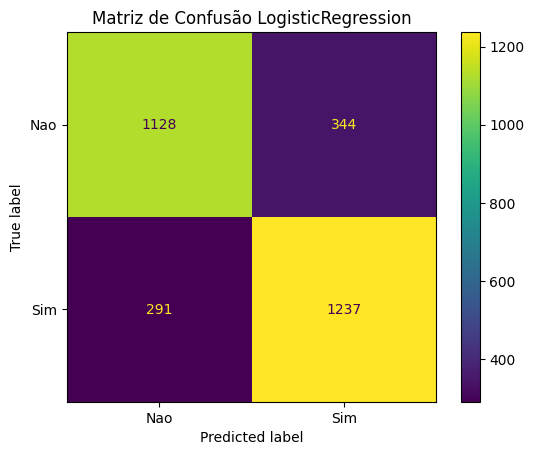

In [43]:
plot_confusion_matrix(y_true, y_pred, 'LogisticRegression')

#### **Utilizando Pipeline + Padronização**

In [44]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import LogisticRegression

# Define o StandardScaler como um Estimator
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

# Define o modelo de Regressão Logística, usando a coluna de features escaladas
lr_scaled = LogisticRegression(featuresCol='scaledFeatures', labelCol='Churn_bin')

# Cria um novo Pipeline com o scaler e o modelo de regressão logística
pipeline_classification = Pipeline(stages=[
    scaler,
    lr_scaled
])

# Agora, o pipeline_classification é um Estimator e pode ser treinado
pipe_classification_model = pipeline_classification.fit(train_data)

print("Novo Pipeline de classificação (com StandardScaler) treinado com sucesso!")

Novo Pipeline de classificação (com StandardScaler) treinado com sucesso!


In [45]:
pred_scaled = pipe_classification_model.transform(test_data)
print('Tabela com as transformações:')
pred_scaled.select("scaledFeatures", "Churn_bin", "prediction", "probability").show(truncate=False)

Tabela com as transformações:
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+----------+-----------------------------------------+
|scaledFeatures                                                                                                                                                                                                                                                                                                                  |Churn_bin|prediction|probability                              |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### **Avaliação**

In [46]:
# Avaliação com Padronização
y_true_scaled = pred_scaled.select("Churn_bin").toPandas()
y_pred_scaled = pred_scaled.select("prediction").toPandas()

print('==='*20)
print("Avaliação com padronização dos dados:")
print('---'*20)
print(classification_report(y_true_scaled, y_pred_scaled))
print('==='*20)

Avaliação com padronização dos dados:
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



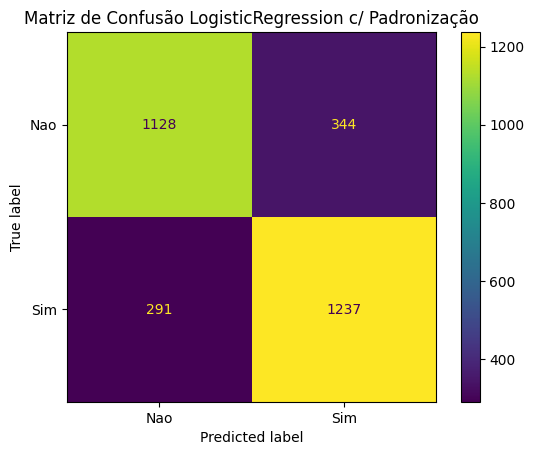

In [47]:
plot_confusion_matrix(y_true_scaled, y_pred_scaled, 'LogisticRegression c/ Padronização')

#### **Comparação de Avaliações**

In [48]:
y_true = pred.select("Churn_bin").toPandas()
y_pred = pred.select("prediction").toPandas()
y_true_scaled = pred_scaled.select("Churn_bin").toPandas()
y_pred_scaled = pred_scaled.select("prediction").toPandas()

print('=='*30)
print('Avaliação S/ padronização:')
print('--'*30)
print(classification_report(y_true, y_pred))
print('=='*30)
print('Avaliação C/ padronização:')
print('--'*30)
print(classification_report(y_true_scaled, y_pred_scaled))
print('=='*30)

Avaliação S/ padronização:
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000

Avaliação C/ padronização:
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



### **RandomForest**

In [49]:
from pyspark.ml.classification import RandomForestClassifier

# Inicializa o modelo de Random Forest
rf = RandomForestClassifier(featuresCol='features', labelCol='Churn_bin', maxDepth=10)

# Treina o modelo com os dados de treinamento
rf_model = rf.fit(train_data)

In [50]:
pred_rf = rf_model.transform(test_data)
#pred_rf.select("features", "Churn_bin", "prediction").show(truncate=False)

Avaliação Random Forest:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.81      1472
         1.0       0.80      0.84      0.82      1528

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



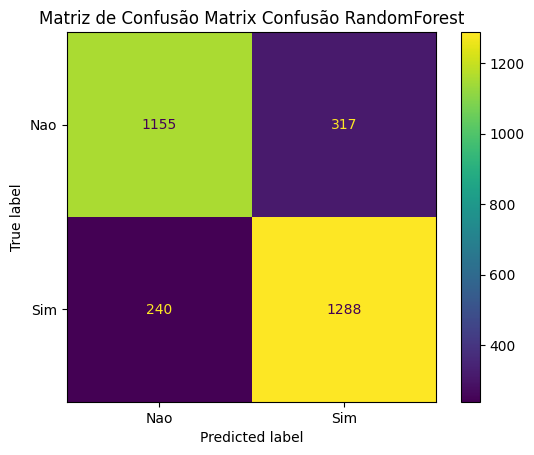

In [51]:
from sklearn.metrics import classification_report

y_true_rf = pred_rf.select("Churn_bin").toPandas()
y_pred_rf = pred_rf.select("prediction").toPandas()

print('===='*20)
print("Avaliação Random Forest:")
print('----'*20)
print(classification_report(y_true_rf, y_pred_rf))
print('===='*20)
plot_confusion_matrix(y_true_rf, y_pred_rf, 'Matrix Confusão RandomForest')

In [52]:
print('=='*30)
print('Avaliação Regressão Logistica S/ padronização:')
print('--'*30)
print(classification_report(y_true, y_pred))
print('=='*30)
print('Avaliação Regressão Logistica C/ padronização:')
print('--'*30)
print(classification_report(y_true_scaled, y_pred_scaled))
print('=='*30)
print('Avaliação Random Forest:')
print('--'*30)
print(classification_report(y_true_rf, y_pred_rf))
print('=='*30)

Avaliação Regressão Logistica S/ padronização:
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000

Avaliação Regressão Logistica C/ padronização:
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000

Avaliação Random Forest:
------------------------------------------------------------
              precision    recall  f1-score 

In [53]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy = MulticlassClassificationEvaluator(labelCol="Churn_bin",
                                             predictionCol="prediction",
                                             metricName="accuracy",).evaluate(pred_rf)
print(f'{accuracy:.3f}')

0.814


#### **Tunagem Hiperparametros**

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


# Modelo
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Churn_bin",
    seed=42
)

# Grid vazio (sem tunagem)
grid_params = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 20, 50])
    .addGrid(rf.maxDepth, [2, 5, 10])
    .addGrid(rf.maxBins, [10, 32, 45])
    .build()
)

# Avaliador
evaluator = MulticlassClassificationEvaluator(
    labelCol="Churn_bin",
    predictionCol="prediction",
    metricName="accuracy"
)

# Cross Validation
rf_cv = CrossValidator(
    estimator = rf,
    estimatorParamMaps = grid_params,
    evaluator = evaluator,
    numFolds = 5,
    seed = 42
)

# Treinamento
cv_model = rf_cv.fit(train_data)

In [56]:

# Predição
pred_cv = cv_model.transform(test_data)

# Accuracy
acc_cv = evaluator.evaluate(pred_cv)

print(f'Accuracy: {acc_cv:.4f}')

Accuracy: 0.8183


Avaliação Tunnig de Hiperparametros (Random Forest):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.79      0.77      0.78      1472
         1.0       0.78      0.81      0.80      1528

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



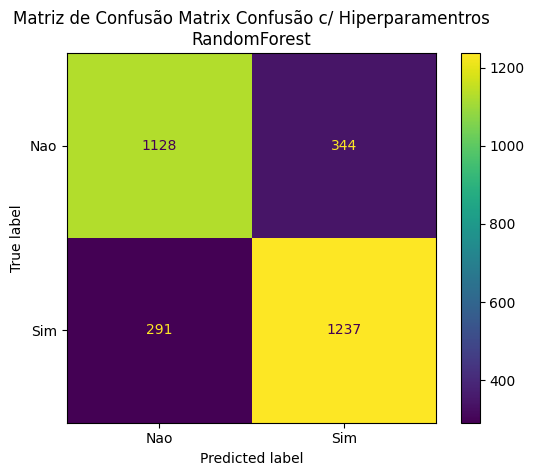

In [57]:
from sklearn.metrics import classification_report

y_true_cv = pred.select("Churn_bin").toPandas()
y_pred_cv = pred.select("prediction").toPandas()

print('===='*20)
print("Avaliação Tunnig de Hiperparametros (Random Forest):")
print('----'*20)
print(classification_report(y_true_cv, y_pred_cv))
print('===='*20)
plot_confusion_matrix(y_true_cv, y_pred_cv, 'Matrix Confusão c/ Hiperparamentros\nRandomForest')

In [58]:
cv_model.avgMetrics

[np.float64(0.759442224322176),
 np.float64(0.7594250390801877),
 np.float64(0.7583075390505727),
 np.float64(0.7848366448322692),
 np.float64(0.7827074025659465),
 np.float64(0.7838559986865165),
 np.float64(0.8113721869570117),
 np.float64(0.8095598299984885),
 np.float64(0.8116813095057764),
 np.float64(0.7638776796665171),
 np.float64(0.7628536031760486),
 np.float64(0.763924783250645),
 np.float64(0.7827163009070551),
 np.float64(0.780366148121933),
 np.float64(0.7827245440728784),
 np.float64(0.8084378582919554),
 np.float64(0.8102228148635341),
 np.float64(0.8142869630325087),
 np.float64(0.7575360802287143),
 np.float64(0.7566447600586585),
 np.float64(0.7573267325040887),
 np.float64(0.7857413107296467),
 np.float64(0.7840588437076311),
 np.float64(0.7859327987379692),
 np.float64(0.8108564622081135),
 np.float64(0.8166236412879627),
 np.float64(0.8127057212818549)]

In [61]:
cv_model.bestModel

RandomForestClassificationModel: uid=RandomForestClassifier_8997d12b0a73, numTrees=50, numClasses=2, numFeatures=24

In [65]:
for param, value in cv_model.bestModel.extractParamMap().items():
    print(f"{param.name}: {value}")

bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: auto
featuresCol: features
impurity: gini
labelCol: Churn_bin
leafCol: 
maxBins: 32
maxDepth: 10
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
numTrees: 50
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 42
subsamplingRate: 1.0


# **Modelo Final**

In [146]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

rf_final = RandomForestClassifier(
    featuresCol= 'features',
    labelCol='Churn_bin',
    maxBins= 32,
    maxDepth= 10,
    numTrees= 50
)

modelo_rf_final = rf_final.fit(train_data)

In [147]:
## Salvando classificador
from pyspark.ml.classification import RandomForestClassificationModel

modelo_rf_final.write().overwrite().save("classificador_rf_final_churn")
print(type(modelo_rf_final))

## Salvando Metadados do melhor modelo
metadados = f'''
    'Modelo': 'RandomForestClassifier',
    'Accuracy': 0.8183,
    'Classification Report:\n{classification_report(y_true_cv, y_pred_cv)}
    'featuresCol': 'features',
    'labelCol':'Churn_bin',
    'maxBins': 32,
    'maxDepth': 10,
    'numTrees': 50
'''

with open("metadata_rf_final_churn.txt", "w") as meta:
    meta.write(metadados)

<class 'pyspark.ml.classification.RandomForestClassificationModel'>


In [148]:
## Salvando o Schema
import json

# Convert the schema to a JSON string and save it to a file
with open('schema_churn.json', 'w') as f:
    json.dump(df.drop('id', 'Churn').schema.jsonValue(), f, indent=4)

# **Classificando Novos Dados**

In [149]:
## Pipeline pre-processador

pipeline_preprocess = PipelineModel.load("pipeline_preprocess_churn")
print("PipelineModel de pré-processamento carregado com sucesso!")

PipelineModel de pré-processamento carregado com sucesso!


In [150]:
from pyspark.ml.classification import RandomForestClassifier

## Classificador salvo
rf_model = RandomForestClassificationModel.load(
    "classificador_rf_final_churn"
)
print("Classificador carregado com sucesso!")

Classificador carregado com sucesso!


In [151]:
## Carregando Schema
import json
from pyspark.sql.types import StructType

with open("/content/schema_churn.json", "r") as f:
    schema = StructType.fromJson(json.load(f))

In [152]:
novo_cliente = spark.createDataFrame([
    (
        0, "Sim", "Sim", 36, "Nao", "Nao",
        "FibraOptica", "Nao", "Sim", "Nao",
        "Sim", "Nao", "Sim",
        "Mensalmente", "Nao", "Boleto", 45.0
    )
], schema=schema)

In [153]:
novo_cliente.show()

+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+-------------+
|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio|MetodoPagamento|MesesCobrados|
+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+-------------+
|         0|    Sim|        Sim|             36|         Nao|                     Nao|FibraOptica|            Nao|         Sim|              Nao|           Sim|    Nao|            Sim| Mensalmente|         Nao|         Boleto|         45.0|
+----------+-------+-----------+----

In [154]:
# Processamento dos dados
novo_cliente = pipeline_preprocess.transform(novo_cliente)

In [155]:
novo_cliente.show()

+----------+-------+-----------+---------------+------------+------------------------+-----------+---------------+------------+-----------------+--------------+-------+---------------+------------+------------+---------------+-------------+-----------+---------------+----------------+----------------------------+-------------------+----------------+---------------------+------------------+-----------+-------------------+----------------+----------------+--------------------+-----------------------+-------------+----------------+-------------------+--------------------+
|Mais65anos|Conjuge|Dependentes|MesesDeContrato|TelefoneFixo|MaisDeUmaLinhaTelefonica|   Internet|SegurancaOnline|BackupOnline|SeguroDispositivo|SuporteTecnico|TVaCabo|StreamingFilmes|TipoContrato|ContaCorreio|MetodoPagamento|MesesCobrados|Conjuge_bin|Dependentes_bin|TelefoneFixo_bin|MaisDeUmaLinhaTelefonica_bin|SegurancaOnline_bin|BackupOnline_bin|SeguroDispositivo_bin|SuporteTecnico_bin|TVaCabo_bin|StreamingFilmes_bin|

In [191]:
# Predição dos dados
predicao = rf_model.transform(novo_cliente)

In [194]:
valor_predicao = predicao.select("prediction").first()[0]
probabilidade = predicao.select("probability").first()[0]

In [195]:
print(f'Classificação:')
if valor_predicao == 0.0:
    print(f"Cliente NÃO irá cancelar o serviço com {probabilidade[0]*100:.2f}%.")
else:
    print(f"Cliente irá cancelar o serviço {probabilidade[1]*100:.2f}%.")

Classificação:
Cliente NÃO irá cancelar o serviço com 77.42%.
